# Практическая работа №4
## Анализ системы с приоритетами

**Тема моделирования:** пункт выдачи заказов с двумя классами клиентов

В работе рассматривается одноканальная система массового обслуживания `M/M/1` с двумя потоками заявок:
- высокоприоритетные клиенты;
- низкоприоритетные клиенты.

Используется **абсолютный вытесняющий приоритет**: если в момент обслуживания низкоприоритетного клиента приходит высокоприоритетный, обслуживание низкоприоритетного клиента прерывается, а высокоприоритетный начинает обслуживаться сразу.


## 1. Описание модели

Рассматривается система массового обслуживания типа `M/M/1` с двумя классами заявок и абсолютным приоритетом **с прерыванием обслуживания**.

Основные предположения модели:
- поток высокоприоритетных заявок является пуассоновским с интенсивностью $\lambda_1$;
- поток низкоприоритетных заявок является пуассоновским с интенсивностью $\lambda_2$;
- время обслуживания каждой заявки распределено по экспоненциальному закону с параметром $\mu$;
- в системе один канал обслуживания;
- при поступлении высокоприоритетной заявки текущая низкоприоритетная заявка вытесняется и возвращается в начало своей очереди;
- внутри каждого класса сохраняется порядок FIFO;
- система устойчива при условии
$$
\rho = \frac{\lambda_1 + \lambda_2}{\mu} < 1.
$$

Время ожидания низкоприоритетной заявки в имитационной модели считается как **суммарное время вне обслуживания**, включая повторные ожидания после вытеснений.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

## 2. Теоретический расчёт характеристик

Обозначим
$$
\rho_1 = \frac{\lambda_1}{\mu}, \qquad
\rho_2 = \frac{\lambda_2}{\mu}, \qquad
\rho = \rho_1 + \rho_2.
$$

Для высокоприоритетных заявок низкоприоритетные клиенты не влияют на порядок обслуживания, поэтому для них система эквивалентна обычной `M/M/1` с параметрами $\lambda_1$ и $\mu$:
$$
W_1 = \frac{1}{\mu - \lambda_1},
$$
$$
W_{q1} = W_1 - \frac{1}{\mu} = \frac{\lambda_1}{\mu(\mu - \lambda_1)},
$$
$$
P_{\text{ож}1} = \rho_1.
$$

Для низкоприоритетных заявок при вытесняющем приоритете среднее время пребывания в системе равно
$$
W_2 = \frac{\mu}{(\mu - \lambda_1)(\mu - \lambda_1 - \lambda_2)}.
$$

Тогда среднее время ожидания низкоприоритетной заявки:
$$
W_{q2} = W_2 - \frac{1}{\mu}.
$$

Вероятность того, что низкоприоритетная заявка будет ждать, равна единице минус вероятность того, что она пришла в пустую систему и успела полностью обслужиться до прихода высокоприоритетной заявки:
$$
P_{\text{ож}2} = 1 - (1 - \rho)\frac{\mu}{\mu + \lambda_1}.
$$

Общие характеристики системы:
$$
L = \lambda_1 W_1 + \lambda_2 W_2,
$$
$$
\rho = \frac{\lambda_1 + \lambda_2}{\mu}.
$$

Во всех численных таблицах время переводится в минуты.


In [2]:
def theoretical_priority_preemptive(lambda1, lambda2, mu):
    rho1 = lambda1 / mu
    rho2 = lambda2 / mu
    rho = rho1 + rho2

    if rho >= 1:
        raise ValueError('Система неустойчива: требуется rho < 1')

    W1 = 1 / (mu - lambda1)
    Wq1 = W1 - 1 / mu
    W2 = mu / ((mu - lambda1) * (mu - lambda1 - lambda2))
    Wq2 = W2 - 1 / mu
    P_wait1 = rho1
    P_wait2 = 1 - (1 - rho) * mu / (mu + lambda1)
    L = lambda1 * W1 + lambda2 * W2

    return {
        'rho1': rho1,
        'rho2': rho2,
        'rho': rho,
        'Wq1': Wq1,
        'W1': W1,
        'P_wait1': P_wait1,
        'Wq2': Wq2,
        'W2': W2,
        'P_wait2': P_wait2,
        'L': L
    }

## 3. Имитационная модель пункта выдачи заказов

В имитационной модели рассматриваются три типа событий:
1. приход высокоприоритетной заявки;
2. приход низкоприоритетной заявки;
3. завершение обслуживания текущей заявки.

Если при обслуживании низкоприоритетной заявки приходит высокоприоритетная заявка, обслуживание прерывается. Оставшееся время обслуживания сохраняется, а вытеснённая заявка возвращается в начало низкоприоритетной очереди.


In [3]:
def simulate_pickup_point_preemptive(lambda1, lambda2, mu, T, seed=None):
    rng = np.random.default_rng(seed)

    current_time = 0.0
    next_high = current_time + (rng.exponential(1 / lambda1) if lambda1 > 0 else np.inf)
    next_low = current_time + (rng.exponential(1 / lambda2) if lambda2 > 0 else np.inf)
    next_departure = np.inf

    high_queue = deque()
    low_queue = deque()

    current_job = None
    service_start_time = None

    area_num_in_system = 0.0
    busy_time = 0.0

    completed = {1: 0, 2: 0}
    wait_sum = {1: 0.0, 2: 0.0}
    system_sum = {1: 0.0, 2: 0.0}
    waited_count = {1: 0, 2: 0}

    def jobs_in_system():
        return len(high_queue) + len(low_queue) + (1 if current_job is not None else 0)

    def start_service(job, now):
        nonlocal current_job, service_start_time, next_departure
        if job['queue_enter_time'] is not None:
            job['wait_accum'] += now - job['queue_enter_time']
            job['queue_enter_time'] = None
        current_job = job
        service_start_time = now
        next_departure = now + job['remaining_service']

    while True:
        event_time = min(next_high, next_low, next_departure, T)

        area_num_in_system += jobs_in_system() * (event_time - current_time)
        if current_job is not None:
            busy_time += event_time - current_time

        current_time = event_time

        if current_time >= T:
            break

        if next_high <= next_low and next_high <= next_departure:
            service_time = rng.exponential(1 / mu)
            job = {
                'class': 1,
                'arrival_time': current_time,
                'remaining_service': service_time,
                'service_time': service_time,
                'wait_accum': 0.0,
                'queue_enter_time': None
            }

            next_high = current_time + (rng.exponential(1 / lambda1) if lambda1 > 0 else np.inf)

            if current_job is None:
                start_service(job, current_time)
            elif current_job['class'] == 2:
                elapsed = current_time - service_start_time
                current_job['remaining_service'] = max(current_job['remaining_service'] - elapsed, 0.0)
                current_job['queue_enter_time'] = current_time
                low_queue.appendleft(current_job)
                start_service(job, current_time)
            else:
                job['queue_enter_time'] = current_time
                high_queue.append(job)

        elif next_low <= next_high and next_low <= next_departure:
            service_time = rng.exponential(1 / mu)
            job = {
                'class': 2,
                'arrival_time': current_time,
                'remaining_service': service_time,
                'service_time': service_time,
                'wait_accum': 0.0,
                'queue_enter_time': None
            }

            next_low = current_time + (rng.exponential(1 / lambda2) if lambda2 > 0 else np.inf)

            if current_job is None:
                start_service(job, current_time)
            else:
                job['queue_enter_time'] = current_time
                low_queue.append(job)

        else:
            finished_job = current_job
            cls = finished_job['class']

            completed[cls] += 1
            wait_sum[cls] += finished_job['wait_accum']
            system_sum[cls] += current_time - finished_job['arrival_time']
            if finished_job['wait_accum'] > 1e-12:
                waited_count[cls] += 1

            current_job = None
            service_start_time = None
            next_departure = np.inf

            if high_queue:
                start_service(high_queue.popleft(), current_time)
            elif low_queue:
                start_service(low_queue.popleft(), current_time)

    return {
        'Wq1_exp': wait_sum[1] / completed[1] if completed[1] > 0 else 0.0,
        'W1_exp': system_sum[1] / completed[1] if completed[1] > 0 else 0.0,
        'P_wait1_exp': waited_count[1] / completed[1] if completed[1] > 0 else 0.0,
        'Wq2_exp': wait_sum[2] / completed[2] if completed[2] > 0 else 0.0,
        'W2_exp': system_sum[2] / completed[2] if completed[2] > 0 else 0.0,
        'P_wait2_exp': waited_count[2] / completed[2] if completed[2] > 0 else 0.0,
        'rho_exp': busy_time / T,
        'L_exp': area_num_in_system / T
    }

## 4. Усреднение по нескольким прогонам

Отдельный прогон имитационной модели зависит от случайных величин, поэтому для устойчивых оценок каждая точка рассчитывается как среднее по нескольким независимым прогонам.


In [4]:
def run_experiment_avg(lambda1, lambda2, mu, T, n_runs=30, base_seed=1000):
    metrics = {
        'Wq1_exp': [],
        'W1_exp': [],
        'P_wait1_exp': [],
        'Wq2_exp': [],
        'W2_exp': [],
        'P_wait2_exp': [],
        'rho_exp': [],
        'L_exp': []
    }

    for i in range(n_runs):
        result = simulate_pickup_point_preemptive(lambda1, lambda2, mu, T, seed=base_seed + i)
        for key in metrics:
            metrics[key].append(result[key])

    return {key: float(np.mean(values)) for key, values in metrics.items()}

## 5. влияние интенсивности потока высокоприоритетных заявок

Фиксируем:
- $\lambda_2 = 5$ заявок в час;
- $\mu = 12$ заявок в час;
- время моделирования одного прогона $T = 5000$ часов;
- число прогонов $100$.

Меняем $\lambda_1$ и сравниваем теоретические и экспериментальные значения.


In [5]:
lambda2_fixed = 5
mu_fixed = 12
T = 5000
n_runs = 100

lambda1_values = np.arange(1.0, 4.6, 0.5)

table_lambda1 = []

wq1_exp_lambda1, wq1_theor_lambda1 = [], []
wq2_exp_lambda1, wq2_theor_lambda1 = [], []

for lambda1 in lambda1_values:
    theor = theoretical_priority_preemptive(lambda1, lambda2_fixed, mu_fixed)
    exp = run_experiment_avg(lambda1, lambda2_fixed, mu_fixed, T=T, n_runs=n_runs)

    table_lambda1.append({
        'λ1': lambda1,
        'Wq1_эксп, мин': exp['Wq1_exp'] * 60,
        'Wq1_теор, мин': theor['Wq1'] * 60,
        'W1_эксп, мин': exp['W1_exp'] * 60,
        'W1_теор, мин': theor['W1'] * 60,
        'Pож1_эксп': exp['P_wait1_exp'],
        'Pож1_теор': theor['P_wait1'],
        'Wq2_эксп, мин': exp['Wq2_exp'] * 60,
        'Wq2_теор, мин': theor['Wq2'] * 60,
        'W2_эксп, мин': exp['W2_exp'] * 60,
        'W2_теор, мин': theor['W2'] * 60,
        'Pож2_эксп': exp['P_wait2_exp'],
        'Pож2_теор': theor['P_wait2'],
        'ρ_эксп': exp['rho_exp'],
        'ρ_теор': theor['rho'],
        'L_эксп': exp['L_exp'],
        'L_теор': theor['L']
    })

    wq1_exp_lambda1.append(exp['Wq1_exp'] * 60)
    wq1_theor_lambda1.append(theor['Wq1'] * 60)
    wq2_exp_lambda1.append(exp['Wq2_exp'] * 60)
    wq2_theor_lambda1.append(theor['Wq2'] * 60)

df_lambda1 = pd.DataFrame(table_lambda1)
df_lambda1.round(4)

,λ1,"Wq1_эксп, мин","Wq1_теор, мин","W1_эксп, мин","W1_теор, мин",Pож1_эксп,Pож1_теор,"Wq2_эксп, мин","Wq2_теор, мин","W2_эксп, мин","W2_теор, мин",Pож2_эксп,Pож2_теор,ρ_эксп,ρ_теор,L_эксп,L_теор
0,1.0,0.4559,0.4545,5.4543,5.4545,0.0835,0.0833,5.8648,5.9091,10.8617,10.9091,0.5369,0.5385,0.4991,0.5000,0.9948,1.0000
1,1.5,0.7093,0.7143,5.7062,5.7143,0.1247,0.1250,7.4165,7.4675,12.4139,12.4675,0.5915,0.5926,0.5407,0.5417,1.1761,1.1818
2,2.0,1.0003,1.0000,6.0005,6.0000,0.1668,0.1667,9.3382,9.4000,14.3357,14.4000,0.6420,0.6429,0.5825,0.5833,1.3929,1.4000
3,2.5,1.3139,1.3158,6.3160,6.3158,0.2079,0.2083,11.7714,11.8421,16.7687,16.8421,0.6889,0.6897,0.6243,0.6250,1.6589,1.6667
4,3.0,1.6670,1.6667,6.6672,6.6667,0.2502,0.2500,14.8569,15.0000,19.8552,20.0000,0.7323,0.7333,0.6660,0.6667,1.9865,2.0000
5,3.5,2.0498,2.0588,7.0528,7.0588,0.2915,0.2917,19.0162,19.2017,24.0139,24.2017,0.7737,0.7742,0.7077,0.7083,2.4108,2.4286
6,4.0,2.4940,2.5000,7.4913,7.5000,0.3327,0.3333,24.7292,25.0000,29.7315,30.0000,0.8120,0.8125,0.7494,0.7500,2.9754,3.0000
7,4.5,2.9951,3.0000,7.9948,8.0000,0.3748,0.3750,33.1062,33.4000,38.1082,38.4000,0.8480,0.8485,0.7912,0.7917,3.7732,3.8000


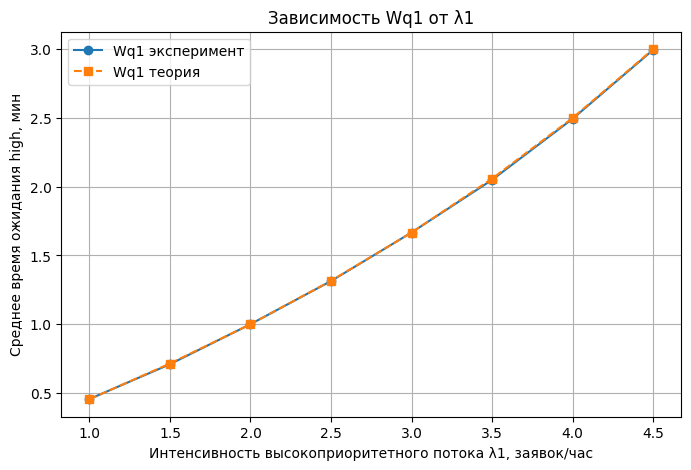

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(lambda1_values, wq1_exp_lambda1, marker='o', label='Wq1 эксперимент')
plt.plot(lambda1_values, wq1_theor_lambda1, marker='s', linestyle='--', label='Wq1 теория')
plt.xlabel('Интенсивность высокоприоритетного потока λ1, заявок/час')
plt.ylabel('Среднее время ожидания high, мин')
plt.title('Зависимость Wq1 от λ1')
plt.grid(True)
plt.legend()
plt.show()

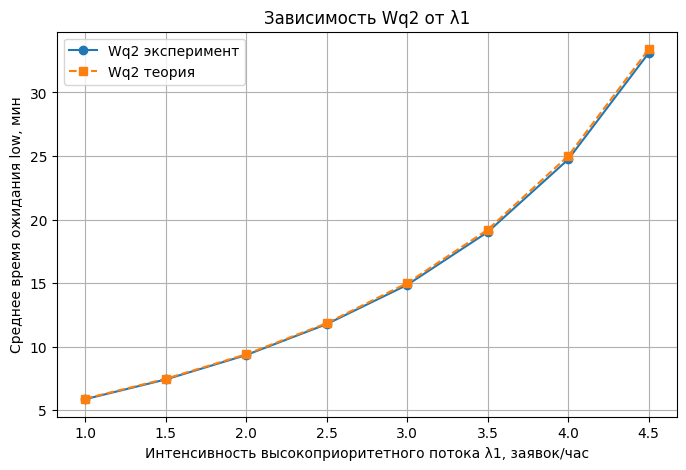

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(lambda1_values, wq2_exp_lambda1, marker='o', label='Wq2 эксперимент')
plt.plot(lambda1_values, wq2_theor_lambda1, marker='s', linestyle='--', label='Wq2 теория')
plt.xlabel('Интенсивность высокоприоритетного потока λ1, заявок/час')
plt.ylabel('Среднее время ожидания low, мин')
plt.title('Зависимость Wq2 от λ1')
plt.grid(True)
plt.legend()
plt.show()

## 6. влияние интенсивности потока низкоприоритетных заявок

Фиксируем:
- $\lambda_1 = 3$ заявки в час;
- $\mu = 12$ заявок в час;
- время моделирования одного прогона $T = 5000$ часов;
- число прогонов $100$.

Меняем $\lambda_2$ и анализируем изменение времени ожидания для обоих классов.


In [8]:
lambda1_fixed = 3
mu_fixed = 12
T = 5000
n_runs = 100

lambda2_values = np.arange(1.0, 6.6, 0.5)

table_lambda2 = []

wq1_exp_lambda2, wq1_theor_lambda2 = [], []
wq2_exp_lambda2, wq2_theor_lambda2 = [], []

for lambda2 in lambda2_values:
    theor = theoretical_priority_preemptive(lambda1_fixed, lambda2, mu_fixed)
    exp = run_experiment_avg(lambda1_fixed, lambda2, mu_fixed, T=T, n_runs=n_runs)

    table_lambda2.append({
        'λ2': lambda2,
        'Wq1_эксп, мин': exp['Wq1_exp'] * 60,
        'Wq1_теор, мин': theor['Wq1'] * 60,
        'W1_эксп, мин': exp['W1_exp'] * 60,
        'W1_теор, мин': theor['W1'] * 60,
        'Pож1_эксп': exp['P_wait1_exp'],
        'Pож1_теор': theor['P_wait1'],
        'Wq2_эксп, мин': exp['Wq2_exp'] * 60,
        'Wq2_теор, мин': theor['Wq2'] * 60,
        'W2_эксп, мин': exp['W2_exp'] * 60,
        'W2_теор, мин': theor['W2'] * 60,
        'Pож2_эксп': exp['P_wait2_exp'],
        'Pож2_теор': theor['P_wait2'],
        'ρ_эксп': exp['rho_exp'],
        'ρ_теор': theor['rho'],
        'L_эксп': exp['L_exp'],
        'L_теор': theor['L']
    })

    wq1_exp_lambda2.append(exp['Wq1_exp'] * 60)
    wq1_theor_lambda2.append(theor['Wq1'] * 60)
    wq2_exp_lambda2.append(exp['Wq2_exp'] * 60)
    wq2_theor_lambda2.append(theor['Wq2'] * 60)

df_lambda2 = pd.DataFrame(table_lambda2)
df_lambda2.round(4)

,λ2,"Wq1_эксп, мин","Wq1_теор, мин","W1_эксп, мин","W1_теор, мин",Pож1_эксп,Pож1_теор,"Wq2_эксп, мин","Wq2_теор, мин","W2_эксп, мин","W2_теор, мин",Pож2_эксп,Pож2_теор,ρ_эксп,ρ_теор,L_эксп,L_теор
0,1.0,1.6650,1.6667,6.6651,6.6667,0.2499,0.25,5.0035,5.0000,9.9996,10.0000,0.4658,0.4667,0.3328,0.3333,0.4990,0.5000
1,1.5,1.6567,1.6667,6.6527,6.6667,0.2497,0.25,5.6402,5.6667,10.6406,10.6667,0.4995,0.5000,0.3744,0.3750,0.5981,0.6000
2,2.0,1.6584,1.6667,6.6553,6.6667,0.2496,0.25,6.3860,6.4286,11.3840,11.4286,0.5323,0.5333,0.4159,0.4167,0.7114,0.7143
3,2.5,1.6695,1.6667,6.6728,6.6667,0.2500,0.25,7.2782,7.3077,12.2697,12.3077,0.5648,0.5667,0.4576,0.4583,0.8436,0.8462
4,3.0,1.6493,1.6667,6.6443,6.6667,0.2489,0.25,8.2836,8.3333,13.2830,13.3333,0.5992,0.6000,0.4991,0.5000,0.9952,1.0000
5,3.5,1.6494,1.6667,6.6419,6.6667,0.2491,0.25,9.4622,9.5455,14.4635,14.5455,0.6322,0.6333,0.5407,0.5417,1.1748,1.1818
6,4.0,1.6484,1.6667,6.6431,6.6667,0.2485,0.25,10.9318,11.0000,15.9328,16.0000,0.6659,0.6667,0.5825,0.5833,1.3932,1.4000
7,4.5,1.6621,1.6667,6.6553,6.6667,0.2498,0.25,12.6713,12.7778,17.6740,17.7778,0.6994,0.7000,0.6243,0.6250,1.6569,1.6667
8,5.0,1.6670,1.6667,6.6672,6.6667,0.2502,0.25,14.8569,15.0000,19.8552,20.0000,0.7323,0.7333,0.6660,0.6667,1.9865,2.0000
9,5.5,1.6587,1.6667,6.6551,6.6667,0.2495,0.25,17.6762,17.8571,22.6780,22.8571,0.7660,0.7667,0.7077,0.7083,2.4096,2.4286


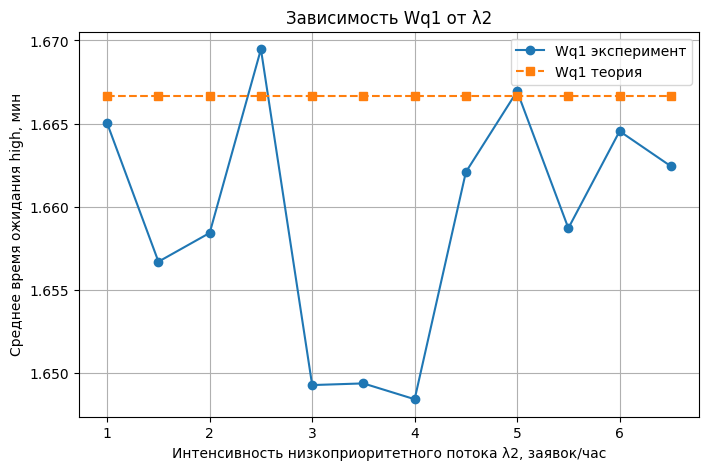

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(lambda2_values, wq1_exp_lambda2, marker='o', label='Wq1 эксперимент')
plt.plot(lambda2_values, wq1_theor_lambda2, marker='s', linestyle='--', label='Wq1 теория')
plt.xlabel('Интенсивность низкоприоритетного потока λ2, заявок/час')
plt.ylabel('Среднее время ожидания high, мин')
plt.title('Зависимость Wq1 от λ2')
plt.grid(True)
plt.legend()
plt.show()

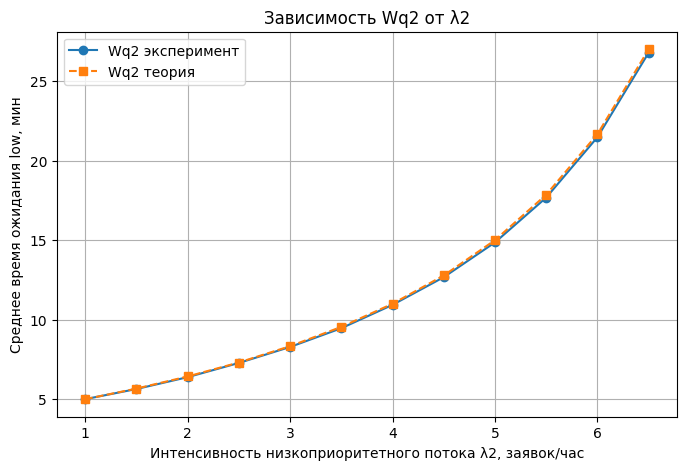

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(lambda2_values, wq2_exp_lambda2, marker='o', label='Wq2 эксперимент')
plt.plot(lambda2_values, wq2_theor_lambda2, marker='s', linestyle='--', label='Wq2 теория')
plt.xlabel('Интенсивность низкоприоритетного потока λ2, заявок/час')
plt.ylabel('Среднее время ожидания low, мин')
plt.title('Зависимость Wq2 от λ2')
plt.grid(True)
plt.legend()
plt.show()

## 7. Анализ результатов

По полученным таблицам и графикам можно сделать следующие выводы:

1. Для высокоприоритетных заявок время ожидания зависит в основном от собственного потока $\lambda_1$ и практически не зависит от интенсивности низкоприоритетных заявок $\lambda_2$.
2. Для низкоприоритетных заявок рост $\lambda_1$ особенно критичен, так как высокоприоритетные клиенты не только занимают канал, но и вытесняют уже начатое низкоприоритетное обслуживание.
3. При увеличении $\lambda_2$ высокоприоритетные заявки почти не страдают, а низкоприоритетные начинают ждать заметно дольше.
4. Экспериментальные значения хорошо согласуются с теоретическими формулами.
5. С ростом суммарной нагрузки $\rho$ среднее число заявок в системе возрастает, а задержки низкоприоритетного потока увеличиваются быстрее.

Таким образом, абсолютный вытесняющий приоритет резко улучшает характеристики высокоприоритетных заявок, но делает систему менее комфортной для низкоприоритетных клиентов.


## 8. Вывод

В ходе практической работы была исследована одноканальная система массового обслуживания с двумя классами заявок и абсолютным вытесняющим приоритетом.

По итогам исследования можно сделать следующие выводы:
1. Высокоприоритетные заявки обслуживаются существенно быстрее и имеют меньшее время ожидания.
2. Низкоприоритетные заявки сильнее зависят от суммарной загрузки системы, особенно от роста потока высокоприоритетных заявок.
3. Вытесняющий приоритет позволяет эффективно обслуживать срочные заявки, но ухудшает показатели для обычных клиентов.
4. Теоретические результаты и результаты моделирования близки друг к другу, что подтверждает корректность модели.

Практически это означает, что использование вытесняющего приоритета оправдано в системах, где критически важна скорость обслуживания части заявок, однако его применение требует контроля общей нагрузки и оценки допустимых задержек для низкоприоритетного потока.
